In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 200

In [16]:
df = pd.read_csv('../AICE/data/california.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [17]:
display(df.info())
df.describe()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


None

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<1H OCEAN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9136
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909,NaN
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874,NaN
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,NaN
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000,NaN
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000,NaN
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000,NaN


In [18]:
df_missing = df.copy()
missing_count = 20

rng = np.random.default_rng(42)

rows = rng.integers(0, df.shape[0], size=20)
cols = rng.integers(0, df.shape[1] - 1, size=20)

print(rows)
print(cols)

for i in range(missing_count):
    df_missing.iloc[rows[i], cols[i]] = np.nan

df_missing.info()

[ 1842 15974 13510  9058  8937 17721  1773 14393  4158  1943 10866 20136
 15185 15709 14808 16224 10592  2644 17332  9295]
[4 3 1 8 7 5 3 7 4 3 4 2 0 4 7 0 7 7 2 5]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20638 non-null  float64
 1   latitude            20639 non-null  float64
 2   housing_median_age  20638 non-null  float64
 3   total_rooms         20637 non-null  float64
 4   total_bedrooms      20429 non-null  float64
 5   population          20638 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20635 non-null  float64
 8   median_house_value  20639 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [19]:
df_missing.isna().sum()

longitude               2
latitude                1
housing_median_age      2
total_rooms             3
total_bedrooms        211
population              2
households              0
median_income           5
median_house_value      1
ocean_proximity         0
dtype: int64

In [20]:
cond = df_missing.isna().any(axis=1)
df[cond]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
290,-122.16,37.77,47.0,1256.0,NaN,570.0,218.0,4.3750,161900.0,NEAR BAY
341,-122.17,37.75,38.0,992.0,NaN,732.0,259.0,1.6196,85100.0,NEAR BAY
538,-122.28,37.78,29.0,5154.0,NaN,3741.0,1273.0,2.5762,173400.0,NEAR BAY
563,-122.24,37.75,45.0,891.0,NaN,384.0,146.0,4.9489,247100.0,NEAR BAY
696,-122.10,37.69,41.0,746.0,NaN,387.0,161.0,3.9063,178400.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20267,-119.19,34.20,18.0,3620.0,NaN,3171.0,779.0,3.3409,220500.0,NEAR OCEAN
20268,-119.18,34.19,19.0,2393.0,NaN,1938.0,762.0,1.6953,167400.0,NEAR OCEAN
20372,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,410700.0,<1H OCEAN
20460,-118.75,34.29,17.0,5512.0,NaN,2734.0,814.0,6.6073,258100.0,<1H OCEAN


In [21]:
df_missing_res = df_missing.dropna()
display(df_missing_res.info())
df_missing_res.isna().values.any()

<class 'pandas.core.frame.DataFrame'>
Index: 20413 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20413 non-null  float64
 1   latitude            20413 non-null  float64
 2   housing_median_age  20413 non-null  float64
 3   total_rooms         20413 non-null  float64
 4   total_bedrooms      20413 non-null  float64
 5   population          20413 non-null  float64
 6   households          20413 non-null  float64
 7   median_income       20413 non-null  float64
 8   median_house_value  20413 non-null  float64
 9   ocean_proximity     20413 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


None

np.False_

In [22]:
Q3 = df_missing_res['median_house_value'].quantile(0.75)
Q1 = df_missing_res['median_house_value'].quantile(0.25)
IQR = Q3 - Q1
print(Q1, Q3, IQR)
print()
print(type(Q1), type(Q3), type(IQR))
upper_bound = IQR + 1.5*Q3
lower_bound = IQR - 1.5*Q1

119500.0 264700.0 145200.0

<class 'numpy.float64'> <class 'numpy.float64'> <class 'numpy.float64'>


<Axes: ylabel='median_house_value'>

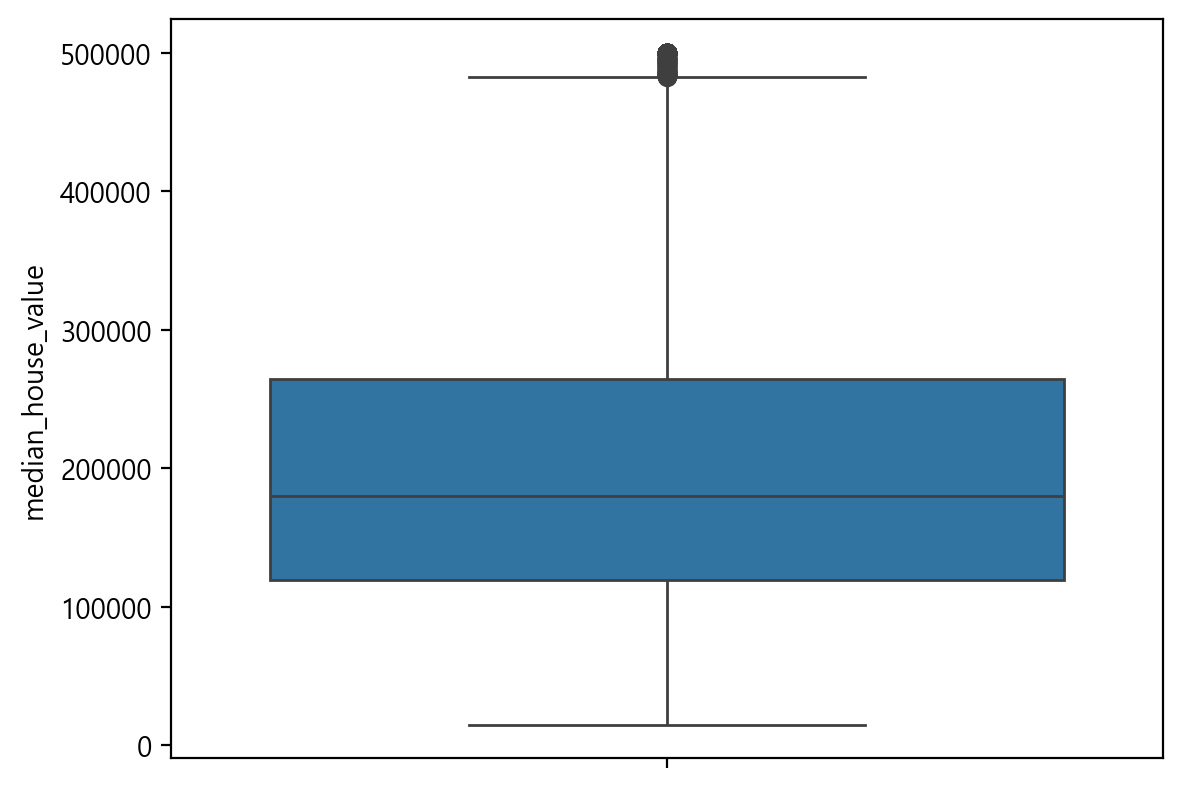

In [27]:
sns.boxplot(data=df_missing_res, y='median_house_value')

In [29]:
outlier_cond = (df_missing_res['median_house_value'] > upper_bound) | (df_missing_res['median_house_value'] < lower_bound)
df_outlier = df_missing_res[cond]
li = df_outlier.index.to_list()

df_missing_res = df_missing_res.drop(li, axis=0)

df_missing_res.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20413 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20413 non-null  float64
 1   latitude            20413 non-null  float64
 2   housing_median_age  20413 non-null  float64
 3   total_rooms         20413 non-null  float64
 4   total_bedrooms      20413 non-null  float64
 5   population          20413 non-null  float64
 6   households          20413 non-null  float64
 7   median_income       20413 non-null  float64
 8   median_house_value  20413 non-null  float64
 9   ocean_proximity     20413 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


C:\Users\heyum\AppData\Local\Temp\ipykernel_13296\2196120886.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_outlier = df_missing_res[cond]
